# Installing Required Libraries

In [1]:
!pip install opencv-python numpy mediapipe pandas tqdm

  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached mediapipe-0.10.21-cp310-cp310-macosx_11_0_universal2.whl.metadata (9.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.6.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (1.3 kB)
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
  Using cached mediapipe-0.10.20-cp310-cp310-macosx_11_0_universal2.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.18-cp310-cp310-macosx_11_0_universal2.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.15-cp310-cp310-macosx_11_0_universal2.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.14-cp310-cp310-macosx_11_0_universa

# Preprocessing

In [2]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import mediapipe as mp
from tqdm import tqdm
from pose_graph_spectral import build_pose_graph

DATASET_PATH = "/Volumes/Dev/Project2/YogaPoseFusion/backend/data/yoga82"
OUTPUT_PATH = "/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed"
IMG_SIZE = (256, 256)

class YogaDataPreprocessor:
    def __init__(self):
        self.mp_pose = mp.solutions.pose
        self.pose = self.mp_pose.Pose(static_image_mode=True, model_complexity=2, min_detection_confidence=0.5)
        os.makedirs(OUTPUT_PATH, exist_ok=True)
        self.pose_list = self._get_pose_list()
        self._save_pose_mapping()

    def _get_pose_list(self):
        train_path = os.path.join(DATASET_PATH, 'train')
        return sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d)) and not d.startswith('.')])

    def _save_pose_mapping(self):
        pose_to_idx = {pose: idx for idx, pose in enumerate(self.pose_list)}
        idx_to_pose = {str(idx): pose for idx, pose in enumerate(self.pose_list)}
        with open(os.path.join(OUTPUT_PATH, 'pose_mapping.json'), 'w') as f:
            json.dump(pose_to_idx, f)
        with open(os.path.join(OUTPUT_PATH, 'idx_to_pose.json'), 'w') as f:
            json.dump(idx_to_pose, f)

    def _extract_landmarks(self, image):
        results = self.pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if not results.pose_landmarks:
            return None
        return np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark])

    def _process_image(self, img_path):
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.resize(img, IMG_SIZE)
        landmarks = self._extract_landmarks(img)
        return img, landmarks

    def process_split(self, split):
        split_path = os.path.join(DATASET_PATH, split)
        if not os.path.exists(split_path):
            print(f"Warning: Split directory {split} not found")
            return None

        data = {'images': [], 'keypoints': [], 'spectral_features': [], 'labels': [], 'label_indices': [], 'image_paths': []}

        for pose_name in tqdm(self.pose_list, desc=f"Processing {split}"):
            class_dir = os.path.join(split_path, pose_name)
            if not os.path.isdir(class_dir):
                continue
            label_idx = self.pose_list.index(pose_name)

            for fname in os.listdir(class_dir):
                if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    continue

                img_path = os.path.join(class_dir, fname)
                img, landmarks = self._process_image(img_path)
                if img is not None and landmarks is not None:
                    data['images'].append(img)
                    data['keypoints'].append(landmarks.flatten())
                    spectral_feats = build_pose_graph(landmarks[:, :3])
                    data['spectral_features'].append(spectral_feats)
                    data['labels'].append(pose_name)
                    data['label_indices'].append(label_idx)
                    data['image_paths'].append(img_path)

        return data

    def save_data(self, split, data):
        if not data or len(data['images']) == 0:
            print(f"No data to save for {split} split")
            return

        np.save(os.path.join(OUTPUT_PATH, f"{split}_images.npy"), np.array(data['images']))
        np.save(os.path.join(OUTPUT_PATH, f"{split}_keypoints.npy"), np.array(data['keypoints']))
        np.save(os.path.join(OUTPUT_PATH, f"{split}_spectral.npy"), np.array(data['spectral_features']))
        np.save(os.path.join(OUTPUT_PATH, f"{split}_labels.npy"), np.array(data['labels']))
        np.save(os.path.join(OUTPUT_PATH, f"{split}_label_indices.npy"), np.array(data['label_indices']))

        pd.DataFrame({
            'image_path': data['image_paths'],
            'label': data['labels'],
            'label_index': data['label_indices']
        }).to_csv(os.path.join(OUTPUT_PATH, f"{split}_metadata.csv"), index=False)

        pd.DataFrame(data['keypoints']).to_csv(os.path.join(OUTPUT_PATH, f"{split}_keypoints.csv"), index=False)
        pd.DataFrame(data['spectral_features']).to_csv(os.path.join(OUTPUT_PATH, f"{split}_spectral.csv"), index=False)

        print(f"Saved {len(data['images'])} samples from {split} split including spectral features.")


if __name__ == '__main__':
    processor = YogaDataPreprocessor()
    
    for split in ['train', 'valid', 'test']:
        data = processor.process_split(split)
        processor.save_data(split, data)


I0000 00:00:1762754116.693664   30407 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Processing train:   0%|                                                                          | 0/82 [00:00<?, ?it/s]W0000 00:00:1762754116.801128   90454 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762754116.841256   90454 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Volumes/Dev/anaconda3/envs/ds/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Processing tra

Saved 10219 samples from train split including spectral features.


Processing valid:  98%|███████████████████████████████████████████████████████████████▍ | 80/82 [04:10<00:05,  2.96s/it][ERROR:0@1183.434] global loadsave.cpp:591 imread_ imread_('/Volumes/Dev/Project2/YogaPoseFusion/backend/data/yoga82/valid/Yogic_sleep_pose/Yogic_sleep_pose_image_76.jpg'): can't read data: OpenCV(4.12.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgcodecs/src/grfmt_gif.cpp:256: error: (-2:Unspecified error) in function 'GifDisposeMethod cv::GifDecoder::readExtensions()'
> Unsupported Dispose Method (expected: 'dm <= GIF_DISPOSE_MAX'), where
>     'dm' is 5
> must be less than or equal to
>     'GIF_DISPOSE_MAX' is 3

Processing valid: 100%|█████████████████████████████████████████████████████████████████| 82/82 [04:13<00:00,  3.09s/it]


Saved 2898 samples from valid split including spectral features.


Processing test: 100%|██████████████████████████████████████████████████████████████████| 82/82 [02:18<00:00,  1.69s/it]


Saved 1556 samples from test split including spectral features.


# checking preprocessed details

Train samples (images): 10219 
Train samples (labels): 10219
Validation samples (images): 2898 
Validation samples (labels): 2898
Test samples (images): 1556 
Test samples (labels): 1556

Train class counts:
 Counter({'Sitting pose 1 (normal)': 314, 'Lord_of_the_Dance_Pose_or_Natarajasana_': 268, 'Standing_Forward_Bend_pose_or_Uttanasana_': 240, 'Virasana_or_Vajrasana': 203, 'Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_': 201, 'Camel_Pose_or_Ustrasana_': 200, 'Supta_Baddha_Konasana_': 199, 'Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_': 197, 'Half_Lord_of_the_Fishes_Pose_or_Ardha_Matsyendrasana_': 197, 'Supported_Headstand_pose_or_Salamba_Sirsasana_': 197, 'Side_Plank_Pose_or_Vasisthasana_': 193, 'Boat_Pose_or_Paripurna_Navasana_': 190, 'Chair_Pose_or_Utkatasana_': 188, 'Upward_Bow_(Wheel)_Pose_or_Urdhva_Dhanurasana_': 188, 'Split pose': 181, 'Child_Pose_or_Balasana_': 180, 'Supta_Virasana_Vajrasana': 174, 'Warrior_II_Pose_or_Virabhadrasana_II_': 171, 'Wide-L

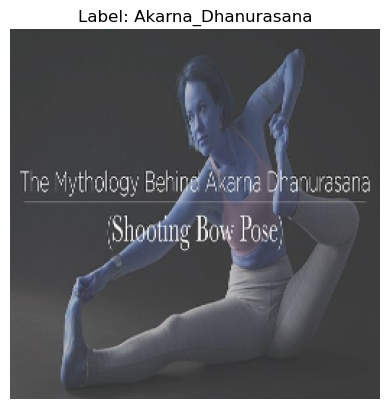

In [1]:
import os
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Set your actual dataset path
DATASET_PATH = '/Volumes/Dev/Project2/YogaPoseFusion/backend/data/yoga82'
PROC_PATH = '/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed'

# Get class names from train (this ensures consistency)
def get_class_folders(split_name):
    split_path = os.path.join(DATASET_PATH, split_name)
    return sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d)) and not d.startswith('.')])

train_labels = np.load(f'{PROC_PATH}/train_labels.npy', allow_pickle=True)
expected_classes = list(Counter(train_labels).keys())


# Load your processed labels and images
train_images = np.load(f'{PROC_PATH}/train_images.npy', allow_pickle=True)
train_labels = np.load(f'{PROC_PATH}/train_labels.npy', allow_pickle=True)
valid_images = np.load(f'{PROC_PATH}/valid_images.npy', allow_pickle=True)
valid_labels = np.load(f'{PROC_PATH}/valid_labels.npy', allow_pickle=True)
test_images = np.load(f'{PROC_PATH}/test_images.npy', allow_pickle=True)
test_labels = np.load(f'{PROC_PATH}/test_labels.npy', allow_pickle=True)

print("Train samples (images):", train_images.shape[0], "\nTrain samples (labels):", train_labels.shape[0])
print("Validation samples (images):", valid_images.shape[0], "\nValidation samples (labels):", valid_labels.shape[0])
print("Test samples (images):", test_images.shape[0], "\nTest samples (labels):", test_labels.shape[0])

print("\nTrain class counts:\n", Counter(train_labels))
print("\nValidation class counts:\n", Counter(valid_labels))
print("\nTest class counts:\n", Counter(test_labels))

found_classes = set(train_labels) | set(valid_labels) | set(test_labels)
missing_classes = set(expected_classes) - found_classes

if missing_classes:
    print("\nMissing classes:", sorted(missing_classes))
else:
    print("\nAll expected classes are present.")

# Optional: Quick visual check
show_idx = 0  # Change this to preview other images
plt.imshow(train_images[show_idx])
plt.title(f'Label: {train_labels[show_idx]}')
plt.axis('off')
plt.show()


In [8]:
from PIL import Image
im = Image.open('/Volumes/Dev/Project/YogaPoseFusion/backend/data/yoga82/valid/Yogic_sleep_pose/Yogic_sleep_pose_image_76.jpg')
im = im.convert('RGB')
im.save('/Volumes/Dev/Project/YogaPoseFusion/backend/data/yoga82/valid/Yogic_sleep_pose/Yogic_sleep_pose_image_76_converted.jpg')